# 📸🗣️ Automated shareable notes from videos

<a href="https://colab.research.google.com/github/video-db/videodb-cookbook/blob/main/examples/conference_slide_scraper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction

In this tutorial, we'll explore an advanced yet accessible technique for retrieving visual information from video content based on spoken word queries. Specifically, we'll focus on finding information on slides in a video recording of a speech.

As video content continues to grow in volume and importance, being able to quickly find specific information within videos becomes crucial. Imagine being able to locate a particular statistic mentioned in an hour-long presentation without watching the entire video. That's the power of multimodal video search!

This approach combines a timed slide-understanding artifact with a queryable transcript to create a robust, multimodal search pipeline. Don't worry if these terms sound complex - we'll break everything down step by step!

**Setup Requirements**
---

**📦  Installing packages**

In [5]:
!pip install -q videodb

**🔑 API keys**
Before proceeding, ensure access to [VideoDB](https://videodb.io). If not, sign up for API access on the respective platforms.

> Get your API key from [VideoDB Console](https://console.videodb.io). ( Free for first 50 uploads, **No credit card required** ) 🎉

In [6]:
import videodb
import os
from getpass import getpass

# Prompt user for API key securely
api_key = getpass("Please enter your VideoDB API Key: ")
os.environ["VIDEO_DB_API_KEY"] = api_key

Please enter your VideoDB API Key: ··········


## Tutorial Walkthrough

---

### 📋 Step 1: Connect to VideoDB

Gear up by establishing a connection to VideoDB

In [7]:
from videodb import connect

# Connect to VideoDB using your API key
conn = connect()
coll = conn.get_collection()

### 🎬 Step 2: Upload the Video

In [8]:
video = coll.upload(url="https://www.youtube.com/watch?v=IEe-5VOv0Js")

### 📸🗣️ Step 3: Understand Spoken Content and Slides

Build the multimodal search workflow in two clear stages:

1. Create a queryable transcript from spoken content.
2. Compare slide configurations and prompts before analyzing the full video.

#### 🗣️ Create a Queryable Transcript
---

In [9]:
transcript_understanding = video.understand(
    analyzers=[{"type": "spoken_words", "name": "transcript"}],
)
transcript_understanding.wait_until_complete()

transcript_analyzer = transcript_understanding.get_analyzer("transcript")


#### Build a Sentence-Level Transcript Index

Turn the analyzer's word timings into sentence-sized records before indexing. This keeps phrase matches tied to short time ranges while the pipeline still returns the slide visible at that moment.

In [10]:
import re

transcript_output = transcript_analyzer.get_output()

sentence_records = []
sentence_words = []

for scene in transcript_output["scenes"]:
    for word in scene["data"]["words"]:
        sentence_words.append(word)

        if re.search(r"""[.!?]+["'”’)\]]*$""", word["text"]):
            sentence_records.append(
                {
                    "start": sentence_words[0]["start"],
                    "end": sentence_words[-1]["end"],
                    "text": " ".join(
                        item["text"] for item in sentence_words
                    ),
                }
            )
            sentence_words = []

if sentence_words:
    sentence_records.append(
        {
            "start": sentence_words[0]["start"],
            "end": sentence_words[-1]["end"],
            "text": " ".join(item["text"] for item in sentence_words),
        }
    )

transcript_index = video.index(
    name="conference_transcript_sentences",
    source=sentence_records,
    use_for=["query"],
    fields={"filter": ["text"]},
)
transcript_index.wait_until_complete()

print(f"✅ Transcript index is ready with {len(sentence_records)} timed sentences!")

✅ Transcript index is ready with 249 timed sentences!


The spoken-word analyzer produces a timestamped transcript, and the query index makes its text available to the phrase-matching pipeline below.

#### 📸️ Find the Right Configuration for Slide Understanding
---

To learn more about video understanding, explore the following guides:

- [Understanding Artifacts](https://videodb-docs-indexing-search-v2.mintlify.app/pages/understand/indexing-pipelines/understanding-artifacts) explains how to create reusable timed understanding artifacts from video. It's ideal for getting started quickly and understanding the primary concepts.

- [Analyzer Outputs](https://videodb-docs-indexing-search-v2.mintlify.app/pages/understand/indexing-pipelines/analyzer-outputs) delves deeper into the timestamped records produced by each analyzer. It covers output shapes and field choices for different needs and preferences.





1. **Compare Slide Segmentation Configurations**

Start with the default scene extraction so there is a visual baseline for comparison.

st20m15f1-0.0-16.049 : 0.0-16.049


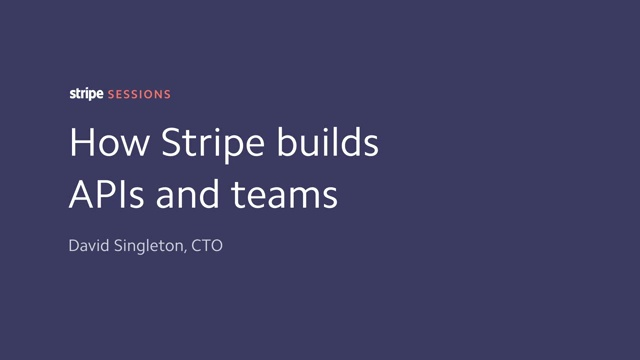

----
st20m15f1-16.049-24.191 : 16.049-24.191


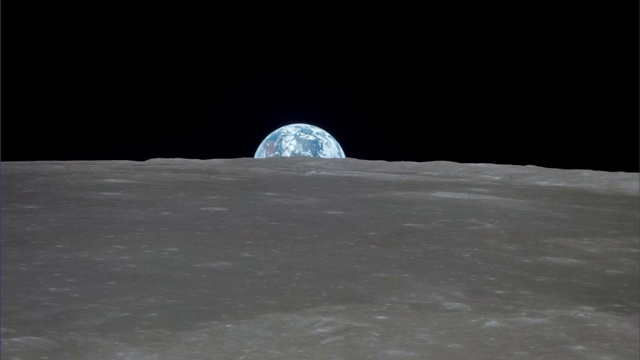

----
st20m15f1-24.191-77.444 : 24.191-77.444


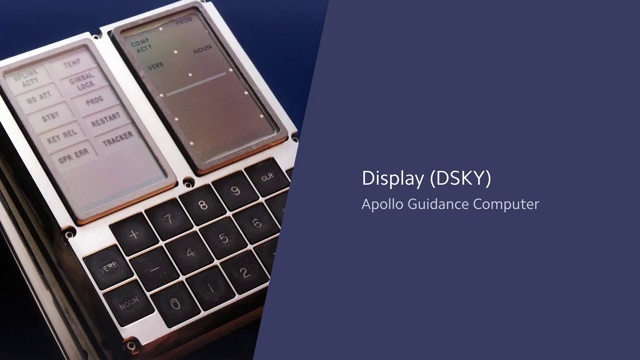

----
st20m15f1-77.444-133.934 : 77.444-133.934


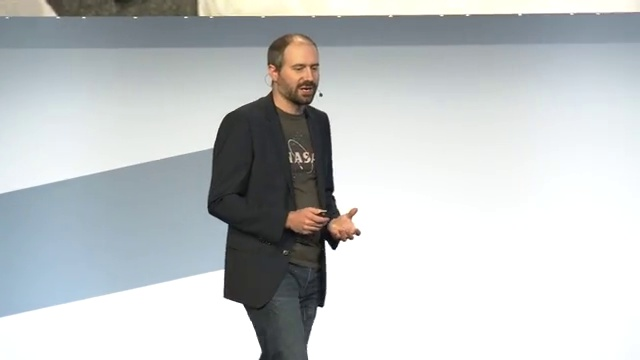

----
st20m15f1-133.934-300.033 : 133.934-300.033


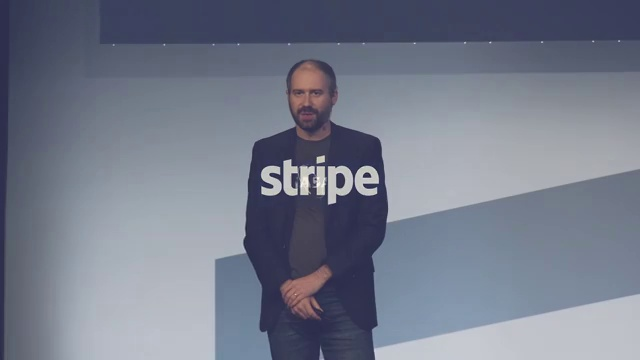

----
st20m15f1-300.0-600.033 : 300.0-600.033


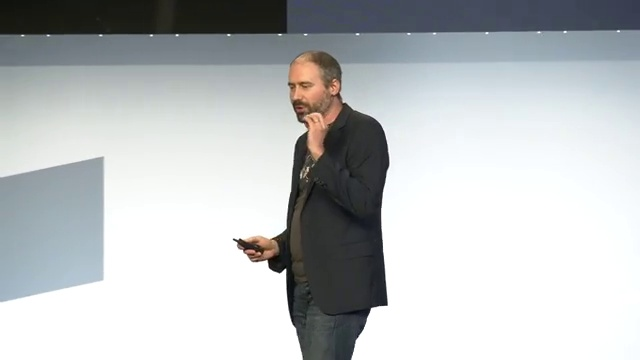

----
st20m15f1-600.0-626.827 : 600.0-626.827


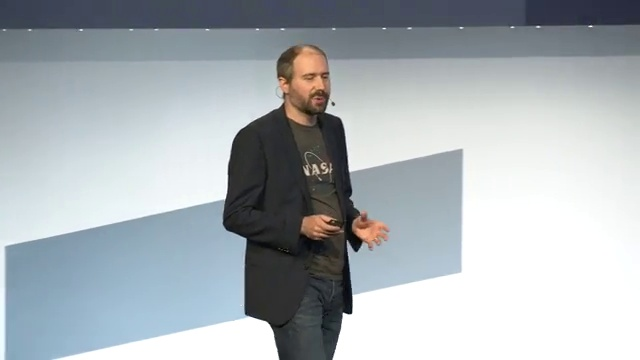

----
st20m15f1-626.827-900.033 : 626.827-900.033


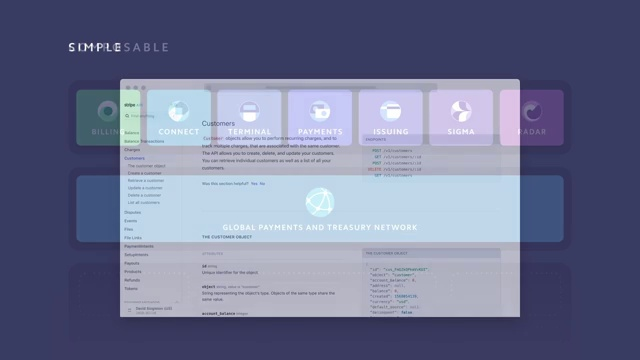

----
st20m15f1-900.0-1200.033 : 900.0-1200.033


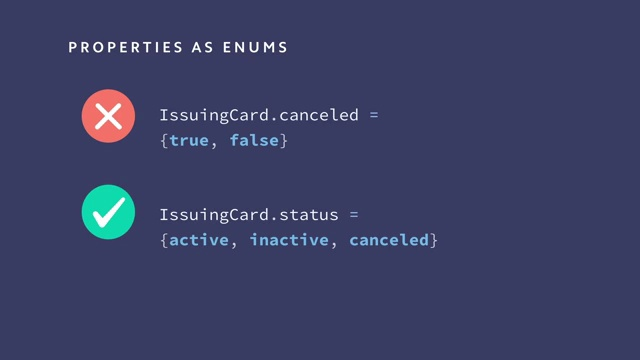

----
st20m15f1-1200.0-1434.034 : 1200.0-1434.034


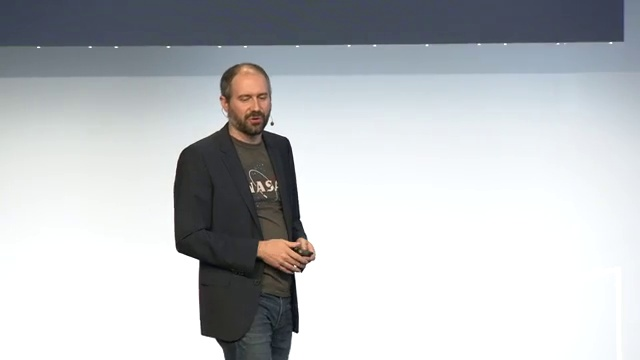

----
st20m15f1-1434.034-1500.033 : 1434.034-1500.033


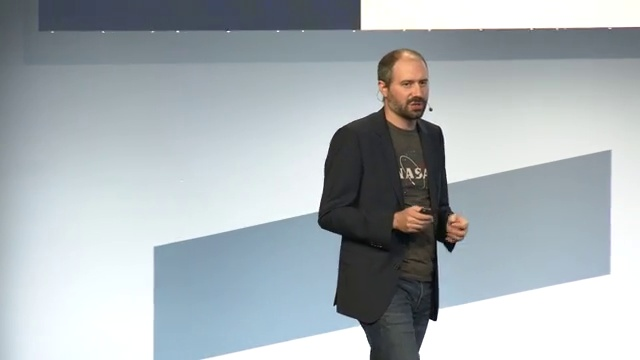

----
st20m15f1-1500.0-1512.145 : 1500.0-1512.145


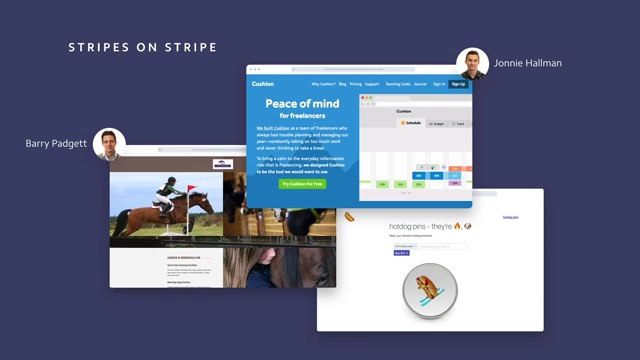

----
st20m15f1-1512.145-1800.033 : 1512.145-1800.033


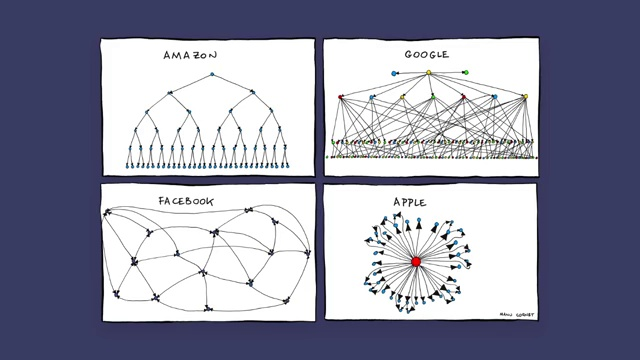

----
st20m15f1-1800.0-1825.659 : 1800.0-1825.659


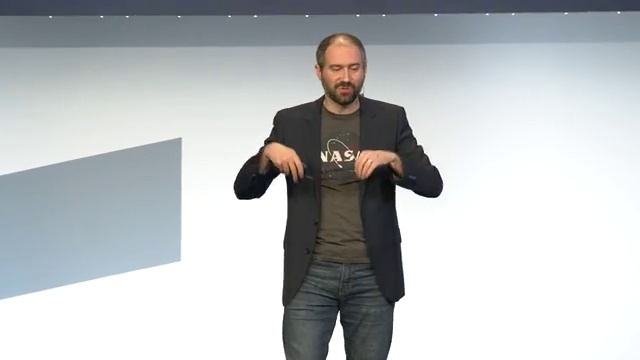

----


In [11]:
from IPython.display import Image, display
import requests


# Helper function to preview extracted scenes
def display_scenes(scenes, images=True):
    for scene in scenes:
        print(f"{scene.id} : {scene.start}-{scene.end}")
        if images:
            for frame in scene.frames:
                image = Image(requests.get(frame.url, stream=True).content)
                display(image)
        print("----")


scene_collection_default = video.extract_scenes()
display_scenes(scene_collection_default.scenes)

</br>
</br>

Conference videos can contain subtle slide changes that the default configuration misses. Lower the shot threshold and compare the extracted scenes again.

In [12]:
from videodb import SceneExtractionType

scene_collection = video.extract_scenes(
    extraction_type=SceneExtractionType.shot_based,
    extraction_config={"threshold": 10},
)
display_scenes(scene_collection.scenes)

Output hidden; open in https://colab.research.google.com to view.

2. ✍️ **Test the Slide Prompt on Sample Scenes**

Test the prompt on a few scenes before analyzing the entire video. This keeps the experiment focused while you check that the analyzer describes slide content and returns "None" when a scene does not show a slide.

In [13]:
slide_prompt = (
    "Give the content written on the slides, output None if it isn't the slides."
)

for scene in scene_collection.scenes[20:23]:
    description = scene.describe(slide_prompt)
    print(f"{scene.id} : {scene.start}-{scene.end}")
    print(description)
    print("-----")

st10m15f1-288.889-300.033 : 288.889-300.033
None
-----
st10m15f1-300.0-302.202 : 300.0-302.202
None
-----
st10m15f1-302.202-352.786 : 302.202-352.786
WORKING BACKWARDS

USER MANUAL < WIREFRAME < FAQ < PRESS RELEASE < CUSTOMER
-----


The lower threshold and sample prompt results provide the configuration for the full slide-analysis run.

### 🎥 Analyze the Video With the Finalized Configuration
---


The final slide run uses the selected configuration:

1. Segment the video into shots with threshold 10.
2. Sample one representative middle frame of each shot.
3. Return a structured slide description for every timed segment.

In [14]:
def display_scene_index(scene_index):
    for scene in scene_index:
        print(f"{scene['start']} - {scene['end']}")
        print(scene["description"])
        print("----")


slide_segmentation = {"type": "shot", "threshold": 10}
slide_sampling = {"strategy": "uniform", "frame_count": 1}
slide_schema = {"description": "string"}

slide_understanding = video.understand(
    segmentation=slide_segmentation,
    analyzers=[
        {
            "type": "vlm",
            "name": "slides",
            "sampling": slide_sampling,
            "config": {"prompt": slide_prompt, "schema": slide_schema},
        }
    ],
)
slide_understanding.wait_until_complete()

slides_analyzer = slide_understanding.get_analyzer("slides")
slides_output = slides_analyzer.get_output()

scene_index = [
    {
        "start": float(segment["start"]),
        "end": float(segment["end"]),
        "description": segment["data"]["description"],
    }
    for segment in slides_output["scenes"]
]

scene_index.sort(key=lambda scene: (scene["start"], scene["end"]))


In [15]:
display_scene_index(scene_index)

0.0 - 5.706
David Singleton, CTO
----
5.706 - 9.376
stripe SESSIONS

How Stripe builds
APIs and teams

David Singleton, CTO
----
9.376 - 14.648
None
----
14.648 - 16.016
None
----
16.016 - 24.258
None
----
24.258 - 40.607
None
----
40.607 - 51.718
Display (DSKY)
Apollo Guidance Computer
----
51.718 - 58.926
None
----
58.926 - 65.065
X-520-62-86
STAR CATALOGS ON PUNCHED CARDS
AND MAGNETIC TAPES—DETAILS
BY
(NASA logo)
----
65.065 - 76.31
None
----
76.31 - 77.444
None
----
77.444 - 99.533
None
----
99.533 - 133.934
None
----
133.934 - 157.124
Core rope memory
1500 bits per cubic inch and 8-week production lead time
----
157.124 - 174.274
APOLLO INSPECTION
----
174.274 - 180.18
APOLLO (across the top of the circular emblem), NASA (across the bottom), with a large stylized letter 'A' in the center of the emblem.
----
180.18 - 202.769
Visible slide text:
- PRODUCTION
- Software gap — a growing crisis for computers
- Shortage of programmers — and the fruits of their solitary art — is stunting

### Step4 : 🔍 Search Pipeline

---

The heart of this approach combines the queryable transcript index with the timed slide artifact.

This pipeline does the following:

1. Finds transcript moments containing a word or phrase.
2. Extracts time ranges from those results.
3. Filters slide descriptions from the local artifact by those time ranges.
4. Returns the matching slide descriptions and their time ranges.

In [16]:
def simple_filter_scenes(time_ranges, scene_dicts):
    def is_in_range(scene, range_start, range_end):
        scene_start = scene["start"]
        scene_end = scene["end"]
        return scene_start < range_end and range_start < scene_end

    filtered_scenes = []
    for start, end in time_ranges:
        filtered_scenes.extend(
            scene
            for scene in scene_dicts
            if is_in_range(scene, start, end)
        )

    # Remove duplicates while preserving order
    seen = set()
    return [
        scene
        for scene in filtered_scenes
        if not (
            (scene["start"], scene["end"]) in seen
            or seen.add((scene["start"], scene["end"]))
        )
    ]

In [17]:
def search_pipeline(query, video):
    # Find matching moments in the transcript index
    search_result = video.query(
        index_id=transcript_index.index_id,
        filter=[{"field": "text", "op": "contains", "value": query}],
        limit=100,
        sort=[("start", "asc")],
    )
    time_ranges = [(shot.start, shot.end) for shot in search_result.get_shots()]

    # Filter slides from the local understanding artifact
    final_result = simple_filter_scenes(time_ranges, scene_index)

    # Return slide descriptions and video timelines for the matching moments
    result_text = "\n\n".join(
        result_entry["description"]
        for result_entry in final_result
        if result_entry.get("description", "").lower().strip() != "none"
    )
    result_timeline = [
        (result_entry.get("start"), result_entry.get("end"))
        for result_entry in final_result
    ]

    return result_text, result_timeline

### 👀 Viewing the Search Results
---

Finally, let's use our search pipeline:

In [18]:
from videodb import play_stream

query = "hard and fast rule"

result_text, result_timeline = search_pipeline(query, video)
# Truncate result_text before printing if it's too long
max_chars = 500
if len(result_text) > max_chars:
    print(result_text[:max_chars] + "...\n<TRUNCATED>")
else:
    print(result_text)

# Get the video's actual length from the video object
video_length = video.length

# Clip the end times in result_timeline to not exceed video_length
clipped_result_timeline = [
    (start, min(end, video_length)) for start, end in result_timeline
]

stream_link = video.generate_stream(clipped_result_timeline)
play_stream(stream_link)

IT'S ALL IN THE DETAILS

Prefer American English for naming
Avoid payment-industry jargon
Timestamp fields should use <verb>_ed_at
Amount properties should also provide a currency
API resources with IDs are top-level
New API resources should be retrieved and listed one way
API resource mutations should be reflected in API responses
Use nested structures for future extensibility
Prefer enums to booleans for new properties
Use a type field for polymorphic objects
Use verbs for properties with side...
<TRUNCATED>


In [19]:
query = "stripe api review"

result_text, result_timeline = search_pipeline(query, video)
# Truncate result_text before printing if it's too long
max_chars = 500
if len(result_text) > max_chars:
    print(result_text[:max_chars] + "...\n<TRUNCATED>")
else:
    print(result_text)

# Get the video's actual length from the video object
video_length = video.length

# Clip the end times in result_timeline to not exceed video_length
clipped_result_timeline = [
    (start, min(end, video_length)) for start, end in result_timeline
]

stream_link = video.generate_stream(clipped_result_timeline)
play_stream(stream_link)

API REVIEW CHECKLIST

API Review: [Insert Title Here]

(brief, contact link after API review job creation?)

Goal block
- Tag API review DRI and other stakeholders here

Summary
Please provide a short description of the change you would like to make. You may want to include alternatives, related prior art, background/rationale, etc. to help reviewers understand why this change is a good change. Please also provide context for how your change fits into any broader sequence of user actions so we c...
<TRUNCATED>


In [20]:
query = "friction log"

result_text, result_timeline = search_pipeline(query, video)
# Truncate result_text before printing if it's too long
max_chars = 500
if len(result_text) > max_chars:
    print(result_text[:max_chars] + "...\n<TRUNCATED>")
else:
    print(result_text)

# Get the video's actual length from the video object
video_length = video.length

# Clip the end times in result_timeline to not exceed video_length
clipped_result_timeline = [
    (start, min(end, video_length)) for start, end in result_timeline
]

stream_link = video.generate_stream(clipped_result_timeline)
play_stream(stream_link)

Internal Terminal Dogfooding Instructions

https://go/terminal-dogfooding-instructions

Stripe! Thanks a ton for your help in dogfooding ahead of our Terminal GA launch!

We're very close to launching Terminal to public beta and then GA.

And we could use your help! There are a ton of different use cases of these integrations to test and polish, and we want to make sure that we've made each of these paths and accompanying docs and dashboard flows as developer-friendly as possible in the time we ...
<TRUNCATED>


## Conclusion
---

This document has outlined a sophisticated approach to multimodal video search, combining a queryable transcript with timed slide understanding. By leveraging VideoDB's understanding and retrieval capabilities, we've created a pipeline that can find specific visual content (in this case, slide information) based on spoken queries.

This technique has broad applications beyond just searching for slides in speeches. It could be adapted for various use cases where visual information needs to be retrieved based on audio content, such as:

* Finding product demonstrations in long-form video content
* Identifying key moments in educational videos
* Searching for specific visual elements in recorded meetings or presentations

As video content continues to grow in importance and volume, tools and techniques like these will become increasingly valuable for efficient information retrieval and analysis.

## Further Steps
---

If you have any questions or feedback. Feel free to reach out to us 🙌🏼

* [Discord](https://colab.research.google.com/corgiredirector?site=https%3A%2F%2Fdiscord.gg%2Fpy9P639jGz)
* [GitHub](https://github.com/video-db)
* [Website](https://colab.research.google.com/corgiredirector?site=https%3A%2F%2Fvideodb.io)
* [Email](ashu@videodb.io)